In [1]:
from IPython.display import HTML
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 10,
})

from sympy import *

from mathprint import *

# https://stackoverflow.com/questions/49145059/how-to-change-printed-representation-of-functions-derivative-in-sympy
latexReplaceRules = {
    # r'{\left(t \right)}':r' ',
    r'\frac{d}{d t}':r'\dot',
    r'\frac{d^{2}}{d t^{2}}':r'\ddot',
}

def latexNew(expr,**kwargs):
    retStr = latex(expr,**kwargs)
    for _,__ in latexReplaceRules.items():
        retStr = retStr.replace(_,__)
    return retStr


init_printing(use_unicode=False)
init_printing(latex_printer=latexNew)

In [2]:
t = symbols('t', real=True)
theta1 = Function('theta1')
theta2 = Function('theta2')
tau    = symbols('tau', real=True)
J, m, l, d, g, b1, b2 = symbols('J m l d g b1 b2', real=True, nonnegative=True)

![|0.4](./images/flyball.png)

Let uas consier are two motions that contribute to kinetic energy:
* upward-downward rotations around $\theta_1$ $\rightarrow T_1$
* planar continous rotations around $\theta_2$ $\rightarrow T_2$

We use __parallel axis theorem__ to compute the get the correct momen of inertia about the given rotation axis.

In [3]:
T1 = simplify( 2*1/2*(J+m*l**2)*diff(theta1(t) ,t)**2 )
T2 = simplify( 2*1/2*(J+m*(l*sin(theta1(t))+d)**2)*diff(theta2(t) ,t)**2 )

mprint('T_1=' + latexNew(T1))
mprint('T_2=' + latexNew(T2))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
V = 2*m*g*l*(1-cos(theta1(t)))

mprint('V=' + latexNew(V))


<IPython.core.display.Math object>

We introudce two damping elements that cause energy lost:
* $R_1$: dissipation by the linear bushing moving along the vertical rod.
* $R_2$: dissipation by the rotating vertical rod.

In [5]:
z    = l-l*cos(theta1(t))
zdot = diff(z, t)

R1 = 1/2*b1*zdot**2
R2 = 1/2*b2*diff(theta2(t))**2

mprint('R_1=' + latexNew(R1))
mprint('R_2=' + latexNew(R2))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
T = T1 + T2  # Total kinetic energy
L = T  - V   # The Lagrangian

dL_dTh = Matrix([diff(L, theta1(t)), diff(L, theta2(t))])

mprint('\\frac{dL}{d\\theta}=' + latexNew(dL_dTh))

<IPython.core.display.Math object>

In [7]:
dL_dThdot = simplify(Matrix([diff(L, diff(theta1(t), t)), diff(L, diff(theta2(t), t))]))

mprint('\\frac{dL}{d\\dot{\\theta}}=' + latexNew(dL_dThdot) )

<IPython.core.display.Math object>

In [8]:
dR1_dThdot = simplify(Matrix([diff(R1, diff(theta1(t), t)), diff(R1, diff(theta2(t), t))]))

mprint('\\frac{dR_1}{d\\dot{\\theta}}=' + latexNew(dR1_dThdot) )

<IPython.core.display.Math object>

In [9]:
dR2_dThdot = simplify(Matrix([diff(R2, diff(theta1(t), t)), diff(R2, diff(theta2(t), t))]))

mprint('\\frac{dR_2}{d\\dot{\\theta}}=' + latexNew(dR2_dThdot) )

<IPython.core.display.Math object>

In [10]:
dL_dThdot_dt = simplify(Matrix([diff(diff(L, diff(theta1(t), t)),t) , diff(diff(L, diff(theta2(t), t)), t)]))
mprint('\\frac{dL}{d\\dot{\\theta} dt}=' + latexNew(dL_dThdot_dt) )


<IPython.core.display.Math object>

In [11]:
eq = simplify(dL_dThdot_dt - dL_dTh + dR1_dThdot + dR2_dThdot)

mprint('\\frac{dL}{d\\dot{\\theta} dt} - \\frac{dL}{d\\theta} + \\frac{dR_1}{d\\dot{\\theta}} + \\frac{dL}{d\\dot{\\theta} dt}=' + latexNew(eq) )


<IPython.core.display.Math object>

In [14]:
eqs = Eq(eq, Matrix([0 , tau]))

In [16]:
odes = solve(eqs, [diff(theta1(t), t, t), diff(theta2(t), t, t)])

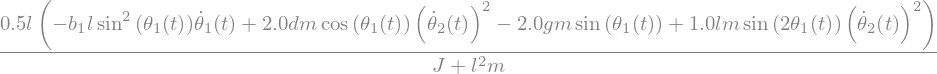

In [23]:
simplify(odes[diff(theta1(t), t, t)])

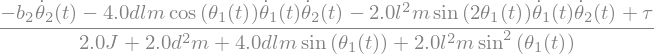

In [24]:
simplify(odes[diff(theta2(t), t, t)])